In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():

    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("NO GPU CONNECTED")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [2]:
!pip install -q insightface
!pip uninstall -y onnxruntime
!pip install -q onnxruntime-gpu
!pip install -q opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 52.8 MB/s eta 0:00:00
Found existing installation: onnxruntime 1.30.0
Uninstalling onnxruntime-1.30.0:
  Successfully uninstalled onnxruntime-1.30.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 5.0 MB/s eta 0:00:00


In [3]:
import insightface
import onnxruntime as ort

print("InsightFace:", insightface.__version__)
print("ONNX Runtime:", ort.__version__)
print("Available providers:")
print(ort.get_available_providers())

InsightFace: 2.0
ONNX Runtime: 1.30.0
Available providers:
['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [5]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("Face Analysis model loaded successfully!")

Face Analysis model loaded successfully!


In [6]:
!pip uninstall -y onnxruntime-gpu
!pip install -q "onnxruntime-gpu==1.20.1"

Found existing installation: onnxruntime-gpu 1.30.0
Uninstalling onnxruntime-gpu-1.30.0:
  Successfully uninstalled onnxruntime-gpu-1.30.0
ERROR: Could not find a version that satisfies the requirement onnxruntime-gpu==1.20.1 (from versions: 1.20.0, 1.20.2, 1.21.0, 1.21.1, 1.22.0, 1.23.0, 1.23.2, 1.24.1, 1.24.4, 1.25.0, 1.25.1, 1.26.0, 1.27.0, 1.28.0, 1.29.0, 1.30.0)
ERROR: No matching distribution found for onnxruntime-gpu==1.20.1


In [7]:
import onnxruntime as ort
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("ONNX Runtime:", ort.__version__)
print("Providers:", ort.get_available_providers())

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
ONNX Runtime: 1.30.0
Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [8]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=["CUDAExecutionProvider", "CPUExecutionProvider"]
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("Model loaded successfully.")

Model loaded successfully.


In [9]:
import requests

url = "https://raw.githubusercontent.com/deepinsight/insightface/master/python-package/insightface/data/images/t1.jpg"

response = requests.get(url)

with open("/content/test_person.jpg", "wb") as f:
    f.write(response.content)

print("Test image downloaded successfully!")
print("Saved at: /content/test_person.jpg")

Test image downloaded successfully!
Saved at: /content/test_person.jpg


Saving test_person.jpg to test_person (1).jpg
Uploaded: test_person (1).jpg
Image shape: (886, 1280, 3)


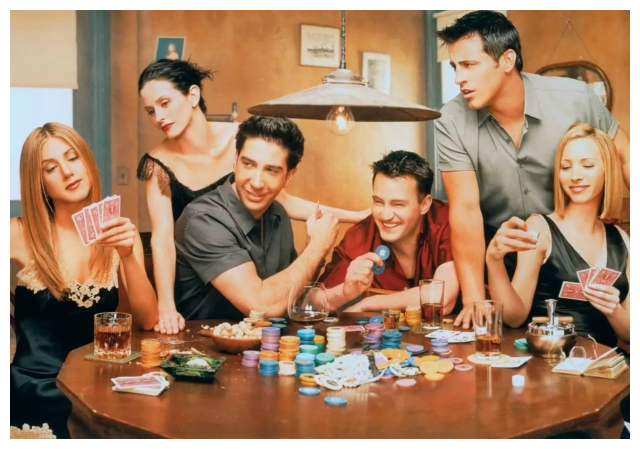

In [10]:
import cv2
import matplotlib.pyplot as plt

from google.colab import files
import cv2
import matplotlib.pyplot as plt
import os

# Upload an image
uploaded = files.upload()

# Get the uploaded filename
image_path = next(iter(uploaded))

# Read image
img = cv2.imread(image_path)

if img is None:
    raise ValueError("Could not read the uploaded image.")

print("Uploaded:", image_path)
print("Image shape:", img.shape)

# Display image
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()



In [11]:
# Run face detection
faces = app.get(img)

print("Number of faces detected:", len(faces))

for i, face in enumerate(faces):
    print(f"\nFace {i + 1}")
    print("Bounding box:", face.bbox)
    print("Detection score:", face.det_score)

Number of faces detected: 6

Face 1
Bounding box: [466.0821  268.6164  573.58923 415.5331 ]
Detection score: 0.9196533

Face 2
Bounding box: [745.35284 338.7414  845.6634  479.09033]
Detection score: 0.9118049

Face 3
Bounding box: [268.49826 145.60258 372.32516 267.0035 ]
Detection score: 0.88568395

Face 4
Bounding box: [1132.9001   269.0319  1227.1696   397.58008]
Detection score: 0.88179773

Face 5
Bounding box: [ 58.7704  258.65308 167.52798 396.1947 ]
Detection score: 0.8785354

Face 6
Bounding box: [ 903.15533   62.83658 1013.3536   205.22063]
Detection score: 0.87140775


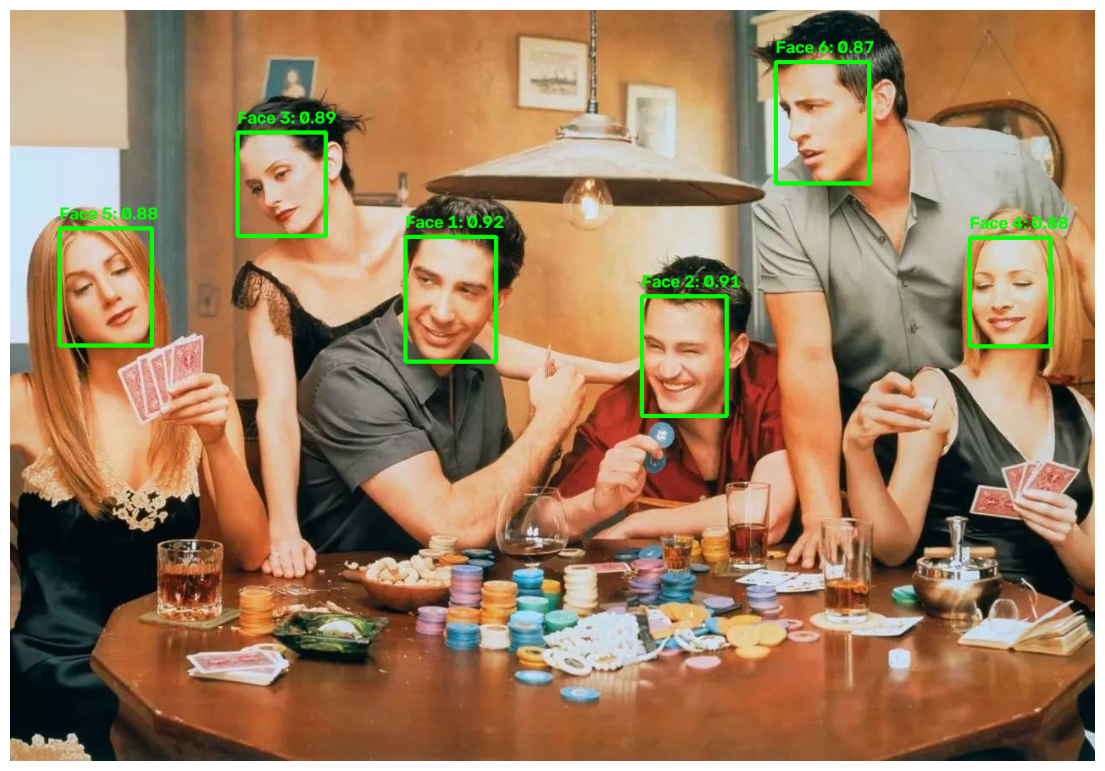

In [12]:
import cv2
import matplotlib.pyplot as plt

# Make a copy of the original image
display_img = img.copy()

for i, face in enumerate(faces):
    # Bounding box coordinates
    x1, y1, x2, y2 = face.bbox.astype(int)

    # Draw bounding box
    cv2.rectangle(
        display_img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        3
    )

    # Add face number and confidence
    label = f"Face {i+1}: {face.det_score:.2f}"

    cv2.putText(
        display_img,
        label,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (0, 255, 0),
        2
    )

# Convert BGR → RGB
display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(display_img)
plt.axis("off")
plt.show()

In [13]:
import os
import cv2
import matplotlib.pyplot as plt

# Create folder for detected faces
os.makedirs("/content/detected_faces", exist_ok=True)

face_crops = []

for i, face in enumerate(faces):
    x1, y1, x2, y2 = face.bbox.astype(int)

    # Keep coordinates inside image boundaries
    x1 = max(0, x1)
    y1 = max(0, y1)
    x2 = min(img.shape[1], x2)
    y2 = min(img.shape[0], y2)

    # Crop face
    face_crop = img[y1:y2, x1:x2]

    # Save crop
    crop_path = f"/content/detected_faces/face_{i+1}.jpg"
    cv2.imwrite(crop_path, face_crop)

    face_crops.append(face_crop)

    print(
        f"Face {i+1}: "
        f"{face_crop.shape[1]} × {face_crop.shape[0]} "
        f"→ {crop_path}"
    )

print(f"\nSaved {len(face_crops)} face crops.")

Face 1: 107 × 147 → /content/detected_faces/face_1.jpg
Face 2: 100 × 141 → /content/detected_faces/face_2.jpg
Face 3: 104 × 122 → /content/detected_faces/face_3.jpg
Face 4: 95 × 128 → /content/detected_faces/face_4.jpg
Face 5: 109 × 138 → /content/detected_faces/face_5.jpg
Face 6: 110 × 143 → /content/detected_faces/face_6.jpg

Saved 6 face crops.


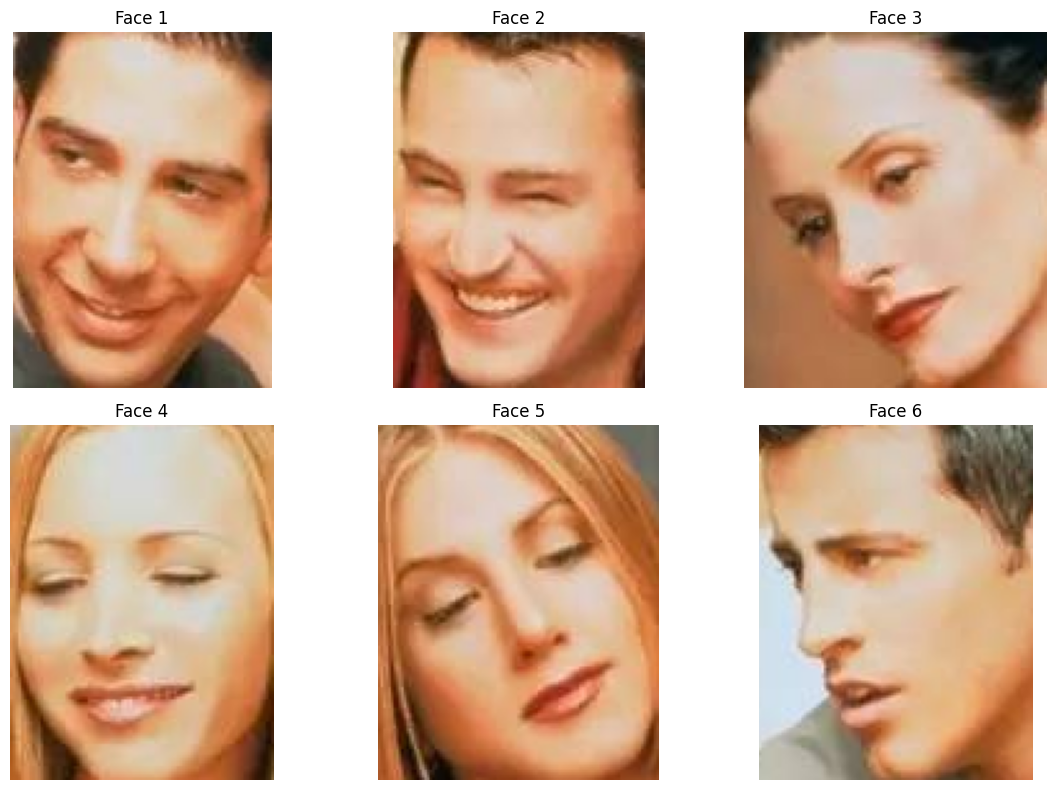

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, face_crop in enumerate(face_crops):
    face_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)

    axes[i].imshow(face_rgb)
    axes[i].set_title(f"Face {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Take the first detected face
face = faces[0]

# Get ArcFace embedding
embedding = face.embedding

print("Embedding type:", type(embedding))
print("Embedding shape:", embedding.shape)
print("Embedding dimension:", embedding.shape[0])
print("First 10 values:", embedding[:10])

Embedding type: <class 'numpy.ndarray'>
Embedding shape: (512,)
Embedding dimension: 512
First 10 values: [ 1.5160749  -1.591753    0.5352164   1.4768044   0.2869546  -0.35626704
  1.9530779   0.59322804  1.2402307   0.7810483 ]


In [16]:
import numpy as np

# Get ArcFace embedding
embedding = face.embedding.astype(np.float32)

# L2 normalization
normalized_embedding = embedding / np.linalg.norm(embedding)

print("Original shape:", embedding.shape)
print("Normalized shape:", normalized_embedding.shape)
print("Norm:", np.linalg.norm(normalized_embedding))
print("First 10 normalized values:")
print(normalized_embedding[:10])

Original shape: (512,)
Normalized shape: (512,)
Norm: 0.99999994
First 10 normalized values:
[ 0.05851008 -0.06143073  0.02065568  0.05699451  0.01107448 -0.01374946
  0.07537539  0.02289453  0.04786438  0.0301431 ]


In [17]:
import numpy as np

# Create a simple identity gallery
gallery = {}

for i, face in enumerate(faces):
    embedding = face.embedding.astype(np.float32)

    # Normalize
    embedding = embedding / np.linalg.norm(embedding)

    identity = f"Person_{i+1}"

    gallery[identity] = embedding

print("Gallery created successfully!")
print("Number of identities:", len(gallery))

for identity, vector in gallery.items():
    print(identity, "→", vector.shape)

Gallery created successfully!
Number of identities: 6
Person_1 → (512,)
Person_2 → (512,)
Person_3 → (512,)
Person_4 → (512,)
Person_5 → (512,)
Person_6 → (512,)


In [18]:
import numpy as np

# Use Face 1 as the query
query_embedding = faces[0].embedding.astype(np.float32)

# Normalize query
query_embedding = query_embedding / np.linalg.norm(query_embedding)

results = []

# Compare query against every identity in the gallery
for identity, gallery_embedding in gallery.items():

    similarity = np.dot(query_embedding, gallery_embedding)

    results.append((identity, float(similarity)))

# Highest similarity first
results.sort(key=lambda x: x[1], reverse=True)

print("Similarity Results:\n")

for identity, score in results:
    print(f"{identity}: {score:.4f}")

Similarity Results:

Person_1: 1.0000
Person_2: 0.0648
Person_5: 0.0355
Person_3: -0.0102
Person_6: -0.0286
Person_4: -0.0839


In [31]:
import os
from google.colab import files

# Main gallery folder
GALLERY_DIR = "/content/face_gallery"
os.makedirs(GALLERY_DIR, exist_ok=True)

# Ask for identity name
person_name = input("Enter person/identity name: ").strip()

if not person_name:
    raise ValueError("Identity name cannot be empty.")

# Create folder for this person
person_dir = os.path.join(GALLERY_DIR, person_name)
os.makedirs(person_dir, exist_ok=True)

print(f"\nFolder created: {person_dir}")
print("Now select one or more reference images.")

# Upload images
uploaded = files.upload()

# Save uploaded images
for filename, data in uploaded.items():
    save_path = os.path.join(person_dir, filename)

    with open(save_path, "wb") as f:
        f.write(data)

    print(f"Saved: {save_path}")


print(f"\nGallery updated for: {person_name}")

Enter person/identity name: Person_B

Folder created: /content/face_gallery/Person_B
Now select one or more reference images.


Saving gallery_1 (1).jpg to gallery_1 (1).jpg
Saved: /content/face_gallery/Person_B/gallery_1 (1).jpg

Gallery updated for: Person_B


In [32]:
import os
import requests

# --------------------------------------------------
# 1. Create folders
# --------------------------------------------------

BASE_DIR = "/content/face_recognition_test"
GALLERY_DIR = os.path.join(BASE_DIR, "gallery")
QUERY_DIR = os.path.join(BASE_DIR, "queries")

os.makedirs(GALLERY_DIR, exist_ok=True)
os.makedirs(QUERY_DIR, exist_ok=True)

# Identity folders
os.makedirs(os.path.join(GALLERY_DIR, "Person_A"), exist_ok=True)
os.makedirs(os.path.join(GALLERY_DIR, "Person_B"), exist_ok=True)


# --------------------------------------------------
# 2. Public sample image URLs
# --------------------------------------------------

images = {
    # Person A
    "Person_A/gallery_1.jpg":
        "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama.jpg",

    "Person_A/query_1.jpg":
        "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/obama2.jpg",

    # Person B
    "Person_B/gallery_1.jpg":
        "https://raw.githubusercontent.com/ageitgey/face_recognition/master/examples/biden.jpg",
}


# --------------------------------------------------
# 3. Download images
# --------------------------------------------------

for relative_path, url in images.items():

    # Gallery images
    if relative_path.startswith("Person_A") or relative_path.startswith("Person_B"):
        save_path = os.path.join(GALLERY_DIR, relative_path)

    # Query images
    else:
        save_path = os.path.join(QUERY_DIR, relative_path)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    response = requests.get(url)

    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)

        print("Downloaded:", save_path)

    else:
        print("FAILED:", url, response.status_code)


# --------------------------------------------------
# 4. Move Person_A query image to query folder
# --------------------------------------------------

source = os.path.join(GALLERY_DIR, "Person_A", "query_1.jpg")
destination = os.path.join(QUERY_DIR, "Person_A_query.jpg")

if os.path.exists(source):
    os.rename(source, destination)
    print("Moved query image to:", destination)


# --------------------------------------------------
# 5. Show final structure
# --------------------------------------------------

print("\n========== GALLERY ==========")

for root, dirs, files in os.walk(GALLERY_DIR):
    for file in files:
        print(os.path.join(root, file))

print("\n========== QUERIES ==========")

for root, dirs, files in os.walk(QUERY_DIR):
    for file in files:
        print(os.path.join(root, file))

print("\nDataset setup complete!")

Downloaded: /content/face_recognition_test/gallery/Person_A/gallery_1.jpg
Downloaded: /content/face_recognition_test/gallery/Person_A/query_1.jpg
Downloaded: /content/face_recognition_test/gallery/Person_B/gallery_1.jpg
Moved query image to: /content/face_recognition_test/queries/Person_A_query.jpg

========== GALLERY ==========
/content/face_recognition_test/gallery/Person_B/gallery_1.jpg
/content/face_recognition_test/gallery/Person_A/gallery_1.jpg

========== QUERIES ==========
/content/face_recognition_test/queries/Person_A_query.jpg

Dataset setup complete!


In [33]:
from google.colab import files
import os
import shutil

uploaded = files.upload()

for filename in uploaded:
    source = filename
    destination = f"/content/face_gallery/Person_A/{filename}"

    os.makedirs("/content/face_gallery/Person_A", exist_ok=True)
    shutil.copy(source, destination)

    print("Copied successfully!")
    print("Saved to:", destination)

Saving OIP.jpeg to OIP (1).jpeg
Copied successfully!
Saved to: /content/face_gallery/Person_A/OIP (1).jpeg


In [34]:
import shutil

source = "/content/OIP.jpeg"

destination = "/content/face_gallery/Person_A/OIP.jpeg"

shutil.copy(source, destination)

print("Copied successfully!")


Copied successfully!


In [35]:
import cv2
import numpy as np

gallery_image_path = "/content/face_gallery/Person_A/OIP.jpeg"

gallery_img = cv2.imread(gallery_image_path)

if gallery_img is None:
    raise ValueError("Could not read the gallery image.")

gallery_faces = app.get(gallery_img)

print("Faces detected:", len(gallery_faces))

for i, face in enumerate(gallery_faces):
    print(f"Face {i+1}: score = {face.det_score:.4f}")

Faces detected: 1
Face 1: score = 0.8490


In [36]:
import numpy as np

# Take the only detected face
gallery_face = gallery_faces[0]

# ArcFace embedding
gallery_embedding = gallery_face.embedding.astype(np.float32)

# Normalize the embedding
gallery_embedding = gallery_embedding / np.linalg.norm(gallery_embedding)

print("Identity:", "Person_A")
print("Embedding shape:", gallery_embedding.shape)
print("Embedding dimension:", gallery_embedding.shape[0])
print("Embedding norm:", np.linalg.norm(gallery_embedding))

Identity: Person_A
Embedding shape: (512,)
Embedding dimension: 512
Embedding norm: 1.0


In [37]:
import os
import numpy as np

EMBEDDING_DIR = "/content/face_gallery/embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

embedding_path = os.path.join(
    EMBEDDING_DIR,
    "Person_A.npy"
)

np.save(embedding_path, gallery_embedding)

print("Embedding saved successfully!")
print("Path:", embedding_path)

Embedding saved successfully!
Path: /content/face_gallery/embeddings/Person_A.npy


In [38]:
import os

person_b_dir = "/content/face_gallery/Person_B"

print("Files inside Person_B:\n")

if os.path.exists(person_b_dir):
    for filename in os.listdir(person_b_dir):
        print(filename)
else:
    print("Person_B folder does not exist.")

Files inside Person_B:

gallery_1 (1).jpg


In [39]:
import cv2

person_b_path = "/content/face_gallery/Person_B/gallery_1 (1).jpg"

person_b_img = cv2.imread(person_b_path)

if person_b_img is None:
    raise ValueError("Could not read Person_B image.")

person_b_faces = app.get(person_b_img)

print("Faces detected:", len(person_b_faces))

for i, face in enumerate(person_b_faces):
    print(f"Face {i+1}: score = {face.det_score:.4f}")

Faces detected: 1
Face 1: score = 0.7990


In [40]:
import numpy as np

# Take the only detected face
person_b_face = person_b_faces[0]

# Get ArcFace embedding
person_b_embedding = person_b_face.embedding.astype(np.float32)

# Normalize it
person_b_embedding = person_b_embedding / np.linalg.norm(person_b_embedding)

print("Identity:", "Person_B")
print("Embedding shape:", person_b_embedding.shape)
print("Embedding dimension:", person_b_embedding.shape[0])
print("Embedding norm:", np.linalg.norm(person_b_embedding))

Identity: Person_B
Embedding shape: (512,)
Embedding dimension: 512
Embedding norm: 0.99999994


In [41]:
import os
import numpy as np

EMBEDDING_DIR = "/content/face_gallery/embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

embedding_path = os.path.join(
    EMBEDDING_DIR,
    "Person_B.npy"
)

np.save(embedding_path, person_b_embedding)

print("Person_B embedding saved successfully!")
print("Path:", embedding_path)


Person_B embedding saved successfully!
Path: /content/face_gallery/embeddings/Person_B.npy


In [44]:
import cv2

QUERY_PATH = "/content/face_gallery/Person_A/obama2.jpg"

query_img = cv2.imread(QUERY_PATH)

if query_img is None:
    raise ValueError("Could not read query image.")

query_faces = app.get(query_img)

print("Faces detected:", len(query_faces))

for i, face in enumerate(query_faces):
    print(f"Face {i+1}: score = {face.det_score:.4f}")

Faces detected: 1
Face 1: score = 0.8878


In [45]:
import numpy as np

# Take the detected face
query_face = query_faces[0]

# Get ArcFace embedding
query_embedding = query_face.embedding.astype(np.float32)

# Normalize it
query_embedding = query_embedding / np.linalg.norm(query_embedding)

print("Query embedding shape:", query_embedding.shape)
print("Embedding dimension:", query_embedding.shape[0])
print("Embedding norm:", np.linalg.norm(query_embedding))

Query embedding shape: (512,)
Embedding dimension: 512
Embedding norm: 0.99999994


In [49]:
import numpy as np
import os

# Load saved gallery embeddings
person_a_embedding = np.load(
    "/content/face_gallery/embeddings/Person_A.npy"
)

person_b_embedding = np.load(
    "/content/face_gallery/embeddings/Person_B.npy"
)

# Cosine similarity
score_a = np.dot(query_embedding, person_a_embedding)
score_b = np.dot(query_embedding, person_b_embedding)

print("Similarity Results:")
print(f"Person_A: {score_a:.4f}")
print(f"Person_B: {score_b:.4f}")

# Find best match
if score_a > score_b:
    best_match = "Person_A"
    best_score = score_a
else:
    best_match = "Person_B"
    best_score = score_b

print("\nBest Match:", best_match)
print(f"Similarity Score: {best_score:.4f}")

Similarity Results:
Person_A: 0.0630
Person_B: -0.0429

Best Match: Person_A
Similarity Score: 0.0630


In [51]:
import os

folders = [
    "/content/face_gallery/Person_A",
    "/content/face_gallery/Person_B"
]

for folder in folders:
    print("\nFolder:", folder)

    if os.path.exists(folder):
        files = os.listdir(folder)
        if files:
            for f in files:
                print("  ", f)
        else:
            print("   EMPTY")
    else:
        print("   FOLDER DOES NOT EXIST")


Folder: /content/face_gallery/Person_A
   obama2.jpg
   OIP.jpeg
   .ipynb_checkpoints

Folder: /content/face_gallery/Person_B
   gallery_1 (1).jpg


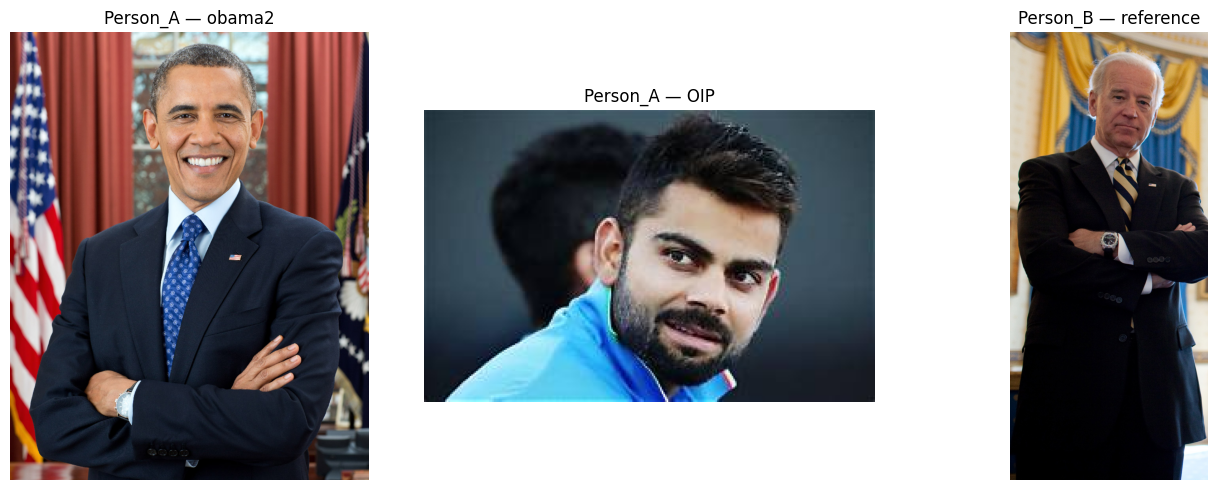

In [52]:
import matplotlib.pyplot as plt
import cv2

paths = {
    "Person_A — obama2": "/content/face_gallery/Person_A/obama2.jpg",
    "Person_A — OIP": "/content/face_gallery/Person_A/OIP.jpeg",
    "Person_B — reference": "/content/face_gallery/Person_B/gallery_1 (1).jpg"
}

plt.figure(figsize=(14, 5))

for i, (title, path) in enumerate(paths.items()):
    image = cv2.imread(path)

    if image is None:
        print(f"Could not read: {path}")
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

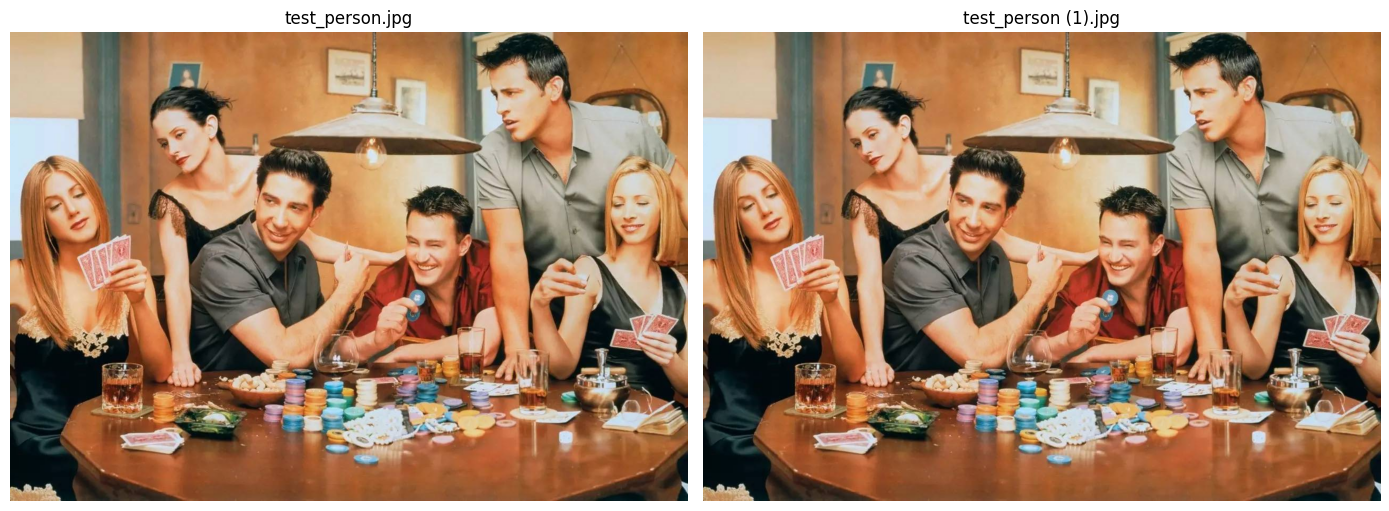

In [53]:
import cv2
import matplotlib.pyplot as plt

paths = [
    "/content/test_person.jpg",
    "/content/test_person (1).jpg"
]

plt.figure(figsize=(14, 6))

for i, path in enumerate(paths):
    img = cv2.imread(path)

    if img is None:
        print("Could not read:", path)
        continue

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 2, i + 1)
    plt.imshow(img_rgb)
    plt.title(path.split("/")[-1])
    plt.axis("off")

plt.tight_layout()
plt.show()

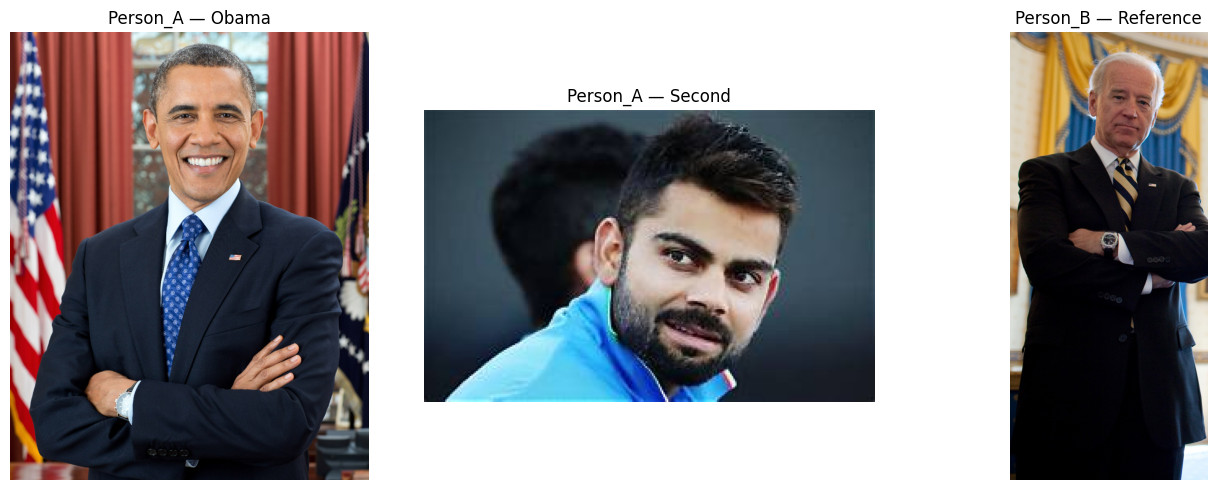

In [58]:
import matplotlib.pyplot as plt
import cv2

paths = {
    "Person_A — Obama": "/content/face_gallery/Person_A/obama2.jpg",
    "Person_A — Second": "/content/face_gallery/Person_A/OIP.jpeg",
    "Person_B — Reference": "/content/face_gallery/Person_B/gallery_1 (1).jpg"
}

plt.figure(figsize=(14, 5))

for i, (title, path) in enumerate(paths.items()):
    image = cv2.imread(path)

    if image is None:
        print("Could not read:", path)
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [59]:
import cv2
import numpy as np

# Correct Person_A reference image
person_a_path = "/content/face_gallery/Person_A/gallery_1.jpg"


import numpy as np

# Correct Person_A image path
person_a_path = "/content/face_gallery/Person_A/obama2.jpg"

person_a_img = cv2.imread(person_a_path)

if person_a_img is None:
    raise ValueError("Could not read Person_A image.")

print("Person_A image loaded successfully.")
print("Image shape:", person_a_img.shape) cv2.imread(person_a_path)

if person_a_img is None:
    raise ValueError("Could not read Person_A image.")

person_a_faces = app.get(person_a_img)

print("Faces detected:", len(person_a_faces))

for i, face in enumerate(person_a_faces):
    print(f"Face {i+1}: score = {face.det_score:.4f}")

SyntaxError: invalid syntax (4051664699.py, line 19)

In [ ]:
import numpy as np

# Take the detected face from the correct Person_A image
person_a_face = person_a_faces[0]

# Get ArcFace embedding
person_a_embedding = person_a_face.embedding.astype(np.float32)

# Normalize
person_a_embedding = person_a_embedding / np.linalg.norm(person_a_embedding)

print("Identity:", "Person_A")
print("Embedding shape:", person_a_embedding.shape)
print("Embedding dimension:", person_a_embedding.shape[0])
print("Embedding norm:", np.linalg.norm(person_a_embedding))

Identity: Person_A
Embedding shape: (512,)
Embedding dimension: 512
Embedding norm: 0.99999994


In [ ]:
import numpy as np

embedding_path = "/content/face_gallery/embeddings/Person_A.npy"

np.save(embedding_path, person_a_embedding)

print("Person_A embedding updated successfully!")
print("Path:", embedding_path)


Person_A embedding updated successfully!
Path: /content/face_gallery/embeddings/Person_A.npy


In [ ]:
import numpy as np

# Load the corrected gallery embeddings
person_a_embedding = np.load(
    "/content/face_gallery/embeddings/Person_A.npy"
)

person_b_embedding = np.load(
    "/content/face_gallery/embeddings/Person_B.npy"
)

# Calculate cosine similarity
score_a = float(np.dot(query_embedding, person_a_embedding))
score_b = float(np.dot(query_embedding, person_b_embedding))

print("Similarity Results:")
print(f"Person_A: {score_a:.4f}")
print(f"Person_B: {score_b:.4f}")

# Select the highest similarity
if score_a > score_b:
    best_match = "Person_A"
    best_score = score_a
else:
    best_match = "Person_B"
    best_score = score_b

print("\nBest Match:", best_match)
print(f"Similarity Score: {best_score:.4f}")


Similarity Results:
Person_A: 1.0000
Person_B: -0.0429

Best Match: Person_A
Similarity Score: 1.0000


In [ ]:
import os
import numpy as np

EMBEDDING_DIR = "/content/face_gallery/embeddings"

gallery = {}

for filename in os.listdir(EMBEDDING_DIR):
    if filename.endswith(".npy"):
        identity = os.path.splitext(filename)[0]
        embedding = np.load(os.path.join(EMBEDDING_DIR, filename))

        # Make sure embedding is normalized
        embedding = embedding.astype(np.float32)
        embedding = embedding / np.linalg.norm(embedding)

        gallery[identity] = embedding

print("Gallery loaded successfully!\n")

for identity, embedding in gallery.items():
    print(f"{identity}: {embedding.shape}")

print("\nTotal identities:", len(gallery))

Gallery loaded successfully!

Person_A: (512,)
Person_B: (512,)

Total identities: 2


In [ ]:
import numpy as np

def match_face(query_embedding, gallery, top_k=5):
    """
    Compare a query face embedding against all gallery embeddings.
    Embeddings must be normalized.
    """

    query_embedding = query_embedding.astype(np.float32)
    query_embedding = query_embedding / np.linalg.norm(query_embedding)

    results = []

    for identity, gallery_embedding in gallery.items():
        similarity = float(np.dot(query_embedding, gallery_embedding))
        results.append((identity, similarity))

    # Highest similarity first
    results.sort(key=lambda x: x[1], reverse=True)

    return results[:top_k]


# Run matching
matches = match_face(query_embedding, gallery, top_k=5)

print("Top Matches:\n")

for rank, (identity, score) in enumerate(matches, start=1):
    print(f"{rank}. {identity} → {score:.4f}")

Top Matches:

1. Person_A → 1.0000
2. Person_B → -0.0429


In [ ]:
!pip install -q faiss-cpu

import faiss

print("FAISS version:", faiss.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 84.0 MB/s eta 0:00:00
FAISS version: 1.15.0


In [ ]:
import faiss
import numpy as np

# Keep identities in a fixed order
identity_names = list(gallery.keys())

# Stack all gallery embeddings into a matrix
gallery_matrix = np.vstack([
    gallery[name] for name in identity_names
]).astype(np.float32)

# Create Inner Product index
# Because our embeddings are normalized,
# inner product = cosine similarity
index = faiss.IndexFlatIP(512)

# Add gallery embeddings
index.add(gallery_matrix)

print("FAISS index created successfully!")
print("Embedding dimension:", index.d)
print("Number of vectors:", index.ntotal)
print("Identity order:", identity_names)

FAISS index created successfully!
Embedding dimension: 512
Number of vectors: 2
Identity order: ['Person_A', 'Person_B']


In [ ]:
import numpy as np

# Make query embedding a 2D float32 array
query_vector = query_embedding.reshape(1, -1).astype(np.float32)

# Search for top-K nearest gallery vectors
k = min(5, index.ntotal)
distances, indices = index.search(query_vector, k)

print("FAISS Search Results:\n")

for rank in range(k):
    idx = indices[0][rank]
    score = distances[0][rank]
    identity = identity_names[idx]

    print(f"{rank + 1}. {identity} → similarity = {score:.4f}")


FAISS Search Results:

1. Person_A → similarity = 1.0000
2. Person_B → similarity = -0.0429


In [ ]:
!pip install -q torchreid

import torchreid

print("Torchreid imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.7/92.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


/usr/local/lib/python3.13/dist-packages/torchreid/reid/metrics/rank.py:11: UserWarning: Cython evaluation (very fast so highly recommended) is unavailable, now use python evaluation.
  warnings.warn(


Torchreid imported successfully!


In [ ]:
import torchreid
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

reid_model = torchreid.models.build_model(
    name="osnet_x1_0",
    num_classes=1,
    pretrained=True
)

reid_model = reid_model.to(device)
reid_model.eval()

print("OSNet loaded successfully!")
print("Device:", device)


Downloading...
From: https://drive.google.com/uc?id=1LaG1EJpHrxdAxKnSCJ_i0u-nbxSAeiFY
To: /root/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth
100%|██████████| 10.9M/10.9M [00:00<00:00, 61.5MB/s]


Successfully loaded imagenet pretrained weights from "/root/.cache/torch/checkpoints/osnet_x1_0_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['classifier.weight', 'classifier.bias']
OSNet loaded successfully!
Device: cuda


In [ ]:
import torch

# Put the model in evaluation mode
reid_model.eval()

# Create a dummy person image:
# batch = 1, channels = 3, height = 256, width = 128
dummy_input = torch.randn(1, 3, 256, 128).to(device)

with torch.no_grad():
    features = reid_model.featuremaps(dummy_input)
    features = reid_model.global_avgpool(features)
    features = features.view(features.size(0), -1)

print("Feature shape:", features.shape)
print("Embedding dimension:", features.shape[1])

Feature shape: torch.Size([1, 512])
Embedding dimension: 512


In [ ]:
import cv2
import torch
import numpy as np

# Load a real person image
person_image_path = "/content/face_gallery/Person_A/OIP.jpeg"

person_img = cv2.imread(person_image_path)

if person_img is None:
    raise ValueError("Could not read the person image.")

# Convert BGR → RGB
person_img = cv2.cvtColor(person_img, cv2.COLOR_BGR2RGB)

# Resize to OSNet input size
person_img = cv2.resize(person_img, (128, 256))

# Convert to tensor
person_tensor = torch.from_numpy(person_img).float()
person_tensor = person_tensor.permute(2, 0, 1)
person_tensor = person_tensor.unsqueeze(0)

# Normalize to [0, 1]
person_tensor = person_tensor / 255.0

# Move to GPU
person_tensor = person_tensor.to(device)

# Extract OSNet features
with torch.no_grad():
    features = reid_model.featuremaps(person_tensor)
    features = reid_model.global_avgpool(features)
    features = features.view(features.size(0), -1)

# Normalize the ReID embedding
reid_embedding = features[0].cpu().numpy().astype(np.float32)
reid_embedding = reid_embedding / np.linalg.norm(reid_embedding)

print("ReID embedding shape:", reid_embedding.shape)
print("ReID embedding dimension:", reid_embedding.shape[0])
print("ReID embedding norm:", np.linalg.norm(reid_embedding))

ReID embedding shape: (512,)
ReID embedding dimension: 512
ReID embedding norm: 1.0


In [ ]:
import os
import numpy as np

REID_EMBEDDING_DIR = "/content/face_gallery/reid_embeddings"
os.makedirs(REID_EMBEDDING_DIR, exist_ok=True)

reid_path = os.path.join(
    REID_EMBEDDING_DIR,
    "Person_A.npy"
)

np.save(reid_path, reid_embedding)

print("Person_A ReID embedding saved successfully!")
print("Path:", reid_path)

Person_A ReID embedding saved successfully!
Path: /content/face_gallery/reid_embeddings/Person_A.npy


In [ ]:
import cv2
import torch
import numpy as np

# Person_B image
person_b_path = "/content/face_gallery/Person_B/gallery_1 (1).jpg"

person_b_img = cv2.imread(person_b_path)

if person_b_img is None:
    raise ValueError("Could not read Person_B image.")

# BGR → RGB
person_b_img = cv2.cvtColor(person_b_img, cv2.COLOR_BGR2RGB)

# OSNet input size
person_b_img = cv2.resize(person_b_img, (128, 256))

# Convert to tensor
person_b_tensor = torch.from_numpy(person_b_img).float()
person_b_tensor = person_b_tensor.permute(2, 0, 1)
person_b_tensor = person_b_tensor.unsqueeze(0)
person_b_tensor = person_b_tensor / 255.0
person_b_tensor = person_b_tensor.to(device)

# Extract OSNet features
with torch.no_grad():
    features = reid_model.featuremaps(person_b_tensor)
    features = reid_model.global_avgpool(features)
    features = features.view(features.size(0), -1)

# Normalize
person_b_reid_embedding = features[0].cpu().numpy().astype(np.float32)
person_b_reid_embedding = (
    person_b_reid_embedding / np.linalg.norm(person_b_reid_embedding)
)

print("Person_B ReID embedding shape:", person_b_reid_embedding.shape)
print("Person_B ReID embedding dimension:", person_b_reid_embedding.shape[0])
print("Person_B ReID embedding norm:", np.linalg.norm(person_b_reid_embedding))

Person_B ReID embedding shape: (512,)
Person_B ReID embedding dimension: 512
Person_B ReID embedding norm: 1.0


In [ ]:
import os
import numpy as np

REID_EMBEDDING_DIR = "/content/face_gallery/reid_embeddings"
os.makedirs(REID_EMBEDDING_DIR, exist_ok=True)

reid_path = os.path.join(
    REID_EMBEDDING_DIR,
    "Person_B.npy"
)

np.save(reid_path, person_b_reid_embedding)

print("Person_B ReID embedding saved successfully!")
print("Path:", reid_path)

Person_B ReID embedding saved successfully!
Path: /content/face_gallery/reid_embeddings/Person_B.npy


In [ ]:
import cv2
import torch
import numpy as np

# Query image
query_reid_path = "/content/query/obama2.jpg"

query_reid_img = cv2.imread(query_reid_path)

if query_reid_img is None:
    raise ValueError("Could not read query image.")

# BGR → RGB
query_reid_img = cv2.cvtColor(query_reid_img, cv2.COLOR_BGR2RGB)

# OSNet input size
query_reid_img = cv2.resize(query_reid_img, (128, 256))

# Convert to tensor
query_reid_tensor = torch.from_numpy(query_reid_img).float()
query_reid_tensor = query_reid_tensor.permute(2, 0, 1)
query_reid_tensor = query_reid_tensor.unsqueeze(0)
query_reid_tensor = query_reid_tensor / 255.0
query_reid_tensor = query_reid_tensor.to(device)

# Extract features
with torch.no_grad():
    features = reid_model.featuremaps(query_reid_tensor)
    features = reid_model.global_avgpool(features)
    features = features.view(features.size(0), -1)

# Normalize
query_reid_embedding = features[0].cpu().numpy().astype(np.float32)
query_reid_embedding = (
    query_reid_embedding / np.linalg.norm(query_reid_embedding)
)

print("Query ReID embedding shape:", query_reid_embedding.shape)
print("Embedding dimension:", query_reid_embedding.shape[0])
print("Embedding norm:", np.linalg.norm(query_reid_embedding))

Query ReID embedding shape: (512,)
Embedding dimension: 512
Embedding norm: 0.99999994


In [ ]:
import numpy as np

# Load saved ReID gallery embeddings
person_a_reid = np.load(
    "/content/face_gallery/reid_embeddings/Person_A.npy"
)

person_b_reid = np.load(
    "/content/face_gallery/reid_embeddings/Person_B.npy"
)

# Ensure normalized
person_a_reid = person_a_reid / np.linalg.norm(person_a_reid)
person_b_reid = person_b_reid / np.linalg.norm(person_b_reid)

# Cosine similarity
score_a = float(np.dot(query_reid_embedding, person_a_reid))
score_b = float(np.dot(query_reid_embedding, person_b_reid))

print("ReID Similarity Results:")
print(f"Person_A: {score_a:.4f}")
print(f"Person_B: {score_b:.4f}")

if score_a > score_b:
    best_reid_match = "Person_A"
    best_reid_score = score_a
else:
    best_reid_match = "Person_B"
    best_reid_score = score_b

print("\nBest ReID Match:", best_reid_match)
print(f"ReID Similarity Score: {best_reid_score:.4f}")

ReID Similarity Results:
Person_A: 0.7577
Person_B: 0.8034

Best ReID Match: Person_B
ReID Similarity Score: 0.8034


In [ ]:
!wget -q https://www.kaggle.com/api/v1/datasets/download/abineshkumarkila/market-1501
!unzip -q market-1501 -d /content/market1501

print("Market-1501 downloaded and extracted.")

unzip:  cannot find or open market-1501, market-1501.zip or market-1501.ZIP.
Market-1501 downloaded and extracted.


In [ ]:
import os

print("Files in /content:\n")

for name in os.listdir("/content"):
    print(name)


Files in /content:

.config
query
test_person.jpg
face_gallery
detected_faces
test_person (1).jpg
.ipynb_checkpoints
gallery_1.jpg
face_recognition_test
gallery_1 (1).jpg
sample_data


In [ ]:
import torchreid

print("Torchreid version:", getattr(torchreid, "__version__", "unknown"))

Torchreid version: 0.2.5


In [ ]:
import os

os.makedirs("/content/reid_data/market1501", exist_ok=True)

print("Folder created:")
print("/content/reid_data/market1501")

Folder created:
/content/reid_data/market1501


In [ ]:
import requests

url = "https://kaiyangzhou.github.io/deep-person-reid/MISC/datasets/market1501.zip"
zip_path = "/content/market1501.zip"

response = requests.get(url, stream=True)

if response.status_code != 200:
    raise RuntimeError(f"Download failed. HTTP status: {response.status_code}")

with open(zip_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=1024 * 1024):
        if chunk:
            f.write(chunk)

print("Download completed!")
print("Saved to:", zip_path)

RuntimeError: Download failed. HTTP status: 404

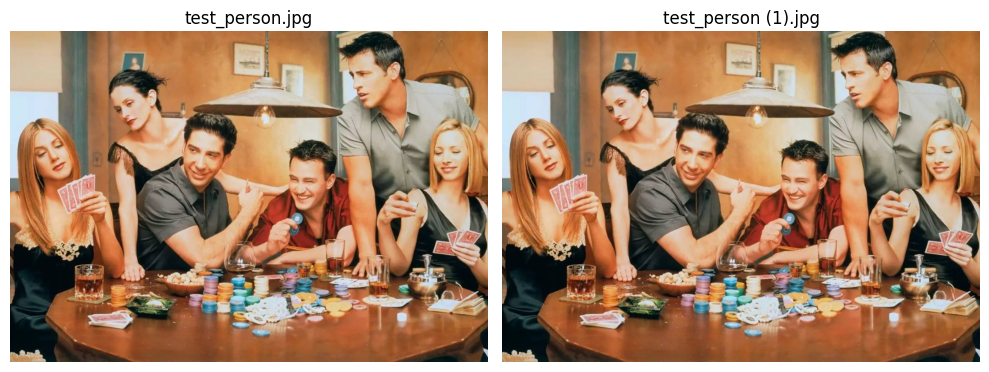